# Guardian AI: Dual-Arm Esports Toxicity Classification & Safety Engine

**Module:** BSc Final Year Project

> **Notice for Evaluators:** This notebook is the primary executable deliverable. It includes its own copy of the moderation rules, prompt, retrieval setup, Gemini client, and live audit flow. The Python files in `ml_classifier/` and `rag_llm/` remain supporting architecture examples, but this notebook does not import or need those folders to run its moderation arm.

I work through the saved dataset, compare the classical models, then try the same chat examples with the retrieval and Gemini arm. For the last part, I keep a small lobby-style monitor in the notebook so messages and their audit results are easy to follow as they come in.

Run **Kernel -> Restart & Run All** from this repository. The API key is read from `.env` or the process environment. The notebook never prints the key. If Gemini or the vector model is unavailable, it says so and uses its local rule fallback instead.


## Section 1: Step 1: EDA and Class Balance

I start by checking the raw labels and dropping rows where the message or target is missing. The plot keeps the project labels visible: 0 is Neutral/Clean, 1 is Mild Toxicity, and 2 is Severe Toxicity.


Loaded 3,267 complete rows from C:\Users\dkshp\OneDrive\Desktop\guardian_ai.worktrees\guardian-ai-repo-restructure-notebook\ml_classifier\data\raw\tagged-data.csv


,Unnamed: 0,match,time,slot,text,target
0,2,2,2263.90490,4,COMMEND ME TY,0
1,7,6,242.54080,8,sorry nex,0
2,11,6,2279.16280,2,what is the best soup?,0
3,18,9,1011.11982,4,man that silence on axe,0
4,21,9,1769.30452,3,not coming into play,0



Class counts:


,Messages
target,
Neutral / Clean,1800
Mild Toxicity,467
Severe Toxicity,1000


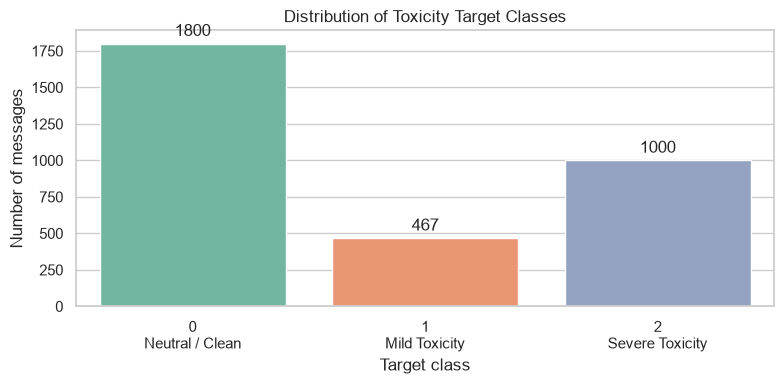

In [12]:
# I keep the imports together so a kernel restart gives me a clean start.

import os
import re
import time
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    f1_score,
)
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
CLASS_NAMES = {0: "Neutral / Clean", 1: "Mild Toxicity", 2: "Severe Toxicity"}


def find_project_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (
            (candidate / "ml_classifier").is_dir()
            or (candidate / "rag_llm").is_dir()
            or (candidate / ".git").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Start Jupyter from the repository "
        "root or one of its subdirectories."
    )


PROJECT_ROOT = find_project_root()


def resolve_data_path(*parts):
    candidates = [
        PROJECT_ROOT.joinpath("data", *parts),
        PROJECT_ROOT.joinpath("ml_classifier", "data", *parts),
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate
    checked = "\n".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Required data file was not found. Checked:\n{checked}")


raw_data_path = resolve_data_path("raw", "tagged-data.csv")
df = pd.read_csv(raw_data_path).dropna(subset=["text", "target"]).copy()
df["target"] = df["target"].astype(int)

print(f"Loaded {len(df):,} complete rows from {raw_data_path}")
display(df.head())
print("\nClass counts:")
display(df["target"].value_counts().sort_index().rename(index=CLASS_NAMES).to_frame("Messages"))

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="target", order=[0, 1, 2], hue="target", palette="Set2", legend=False)
ax.set_xticks([0, 1, 2], [f"{label}\n{CLASS_NAMES[label]}" for label in [0, 1, 2]])
ax.set_title("Distribution of Toxicity Target Classes")
ax.set_xlabel("Target class")
ax.set_ylabel("Number of messages")
for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height())}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        xytext=(0, 3),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()


## Section 2: Step 2: Saved Train and Test Splits

I use the pre-saved stratified splits so the notebook stays comparable with the rest of the project. It checks `data/` first and then the existing `ml_classifier/data/` layout.


In [13]:
# I read the saved splits rather than quietly making a different split here.

train_path = resolve_data_path("processed", "train.csv")
test_path = resolve_data_path("processed", "test.csv")
train_df = pd.read_csv(train_path).dropna(subset=["text", "target"]).copy()
test_df = pd.read_csv(test_path).dropna(subset=["text", "target"]).copy()

X_train = train_df["text"].astype(str)
y_train = train_df["target"].astype(int)
X_test = test_df["text"].astype(str)
y_test = test_df["target"].astype(int)

if set(y_train.unique()) != {0, 1, 2} or set(y_test.unique()) != {0, 1, 2}:
    raise ValueError("Both saved splits must contain all target classes 0, 1, and 2.")
if y_train.value_counts().min() < 5:
    raise ValueError("At least five training examples per class are required for 5-fold CV.")

print(f"Training rows: {len(X_train):,} ({train_path})")
print(f"Test rows:     {len(X_test):,} ({test_path})")
display(pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index(),
}).rename(index=CLASS_NAMES))


Training rows: 2,613 (C:\Users\dkshp\OneDrive\Desktop\guardian_ai.worktrees\guardian-ai-repo-restructure-notebook\ml_classifier\data\processed\train.csv)
Test rows:     327 (C:\Users\dkshp\OneDrive\Desktop\guardian_ai.worktrees\guardian-ai-repo-restructure-notebook\ml_classifier\data\processed\test.csv)


,Train,Test
target,,
Neutral / Clean,1440,180
Mild Toxicity,373,47
Severe Toxicity,800,100


## Section 3: Step 3: TF-IDF Features

I fit the requested unigram and bigram vocabulary on the training text only. That way, the held-out test messages do not influence the features.


In [14]:
# I learn the vocabulary from training messages, then reuse it for the test set.

vectorizer = TfidfVectorizer(max_features=4000, min_df=2, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Training TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test TF-IDF shape:     {X_test_tfidf.shape}")
print(f"Vocabulary size:       {len(vectorizer.vocabulary_):,}")


Training TF-IDF shape: (2613, 1590)
Test TF-IDF shape:     (327, 1590)
Vocabulary size:       1,590


## Section 4: Step 4: Five-Fold Stratified Cross-Validation

I keep the same shuffled folds for each model. This gives me a steadier comparison than relying on one split of the training data.


In [15]:
# I use one fixed stratified fold setup for a fair model comparison.

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_models = {
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Logistic Regression": LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Linear SVM (SGD)": SGDClassifier(
        loss="hinge", penalty="l2", alpha=1e-4, class_weight="balanced",
        max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150, min_samples_split=5, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        objective="multi:softprob", num_class=3, eval_metric="mlogloss",
        random_state=42, n_jobs=1, verbosity=0
    ),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(100, 50), activation="relu", solver="adam",
        alpha=0.0001, max_iter=300, random_state=42
    ),
}
base_models["Voting Classifier"] = VotingClassifier(
    estimators=[
        ("lr", base_models["Logistic Regression"]),
        ("rf", base_models["Random Forest"]),
        ("xgb", base_models["XGBoost"]),
    ],
    voting="soft",
    n_jobs=1,
)

trained_models = {}
cv_results = []
for model_name, model in base_models.items():
    print(f"Running 5-fold CV and fitting {model_name}...")
    scores = cross_val_score(
        model, X_train_tfidf, y_train, cv=cv_strategy, scoring="accuracy", n_jobs=1
    )
    model.fit(X_train_tfidf, y_train)
    trained_models[model_name] = model
    cv_results.append({
        "Model": model_name,
        "CV Accuracy (mean)": scores.mean(),
        "CV Accuracy (std)": scores.std(),
    })
    print(f"  CV accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

cv_leaderboard = pd.DataFrame(cv_results).sort_values(
    "CV Accuracy (mean)", ascending=False
).reset_index(drop=True)
display(cv_leaderboard.style.format({
    "CV Accuracy (mean)": "{:.4f}", "CV Accuracy (std)": "{:.4f}"
}))


Running 5-fold CV and fitting Naive Bayes...
  CV accuracy: 0.7604 (+/- 0.0070)
Running 5-fold CV and fitting Logistic Regression...
  CV accuracy: 0.7838 (+/- 0.0200)
Running 5-fold CV and fitting Linear SVM (SGD)...
  CV accuracy: 0.7696 (+/- 0.0178)
Running 5-fold CV and fitting Random Forest...
  CV accuracy: 0.7876 (+/- 0.0136)
Running 5-fold CV and fitting XGBoost...
  CV accuracy: 0.7826 (+/- 0.0146)
Running 5-fold CV and fitting Neural Network (MLP)...
  CV accuracy: 0.7352 (+/- 0.0101)
Running 5-fold CV and fitting Voting Classifier...
  CV accuracy: 0.8025 (+/- 0.0238)


,Model,CV Accuracy (mean),CV Accuracy (std)
0,Voting Classifier,0.8025,0.0238
1,Random Forest,0.7876,0.0136
2,Logistic Regression,0.7838,0.0200
3,XGBoost,0.7826,0.0146
4,Linear SVM (SGD),0.7696,0.0178
5,Naive Bayes,0.7604,0.0070
6,Neural Network (MLP),0.7352,0.0101


## Section 5: Step 5: Test Set Leaderboard

I score each fitted model once on the held-out test data. Macro scores matter here because they give each toxicity class a voice in the comparison.


In [16]:
# I keep all seven test-set predictions so the leaderboard and plots use the same run.

evaluation_results = []
test_predictions = {}
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_tfidf)
    test_predictions[model_name] = y_pred
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro-Precision": precision,
        "Macro-Recall": recall,
        "Macro-F1": macro_f1,
    })

leaderboard_df = pd.DataFrame(evaluation_results).sort_values(
    "Macro-F1", ascending=False
).reset_index(drop=True)
print("Held-out test-set leaderboard (sorted by Macro-F1):")
display(leaderboard_df.style.format({
    "Accuracy": "{:.4f}", "Macro-Precision": "{:.4f}",
    "Macro-Recall": "{:.4f}", "Macro-F1": "{:.4f}",
}))


Held-out test-set leaderboard (sorted by Macro-F1):


,Model,Accuracy,Macro-Precision,Macro-Recall,Macro-F1
0,Linear SVM (SGD),0.8135,0.7611,0.7228,0.7374
1,Voting Classifier,0.8104,0.7749,0.7015,0.7256
2,Random Forest,0.8012,0.7471,0.7094,0.7241
3,Logistic Regression,0.7798,0.7190,0.6995,0.7074
4,XGBoost,0.7676,0.7672,0.6421,0.6737
5,Neural Network (MLP),0.7554,0.6813,0.6554,0.6642
6,Naive Bayes,0.7645,0.7762,0.6064,0.6215


## Section 6: Step 6: Confusion Matrices and Champion Model

I use the confusion matrices to see which classes are being mixed up, then keep the highest Macro-F1 model with its vectorizer in `models/champion_model.pkl`.


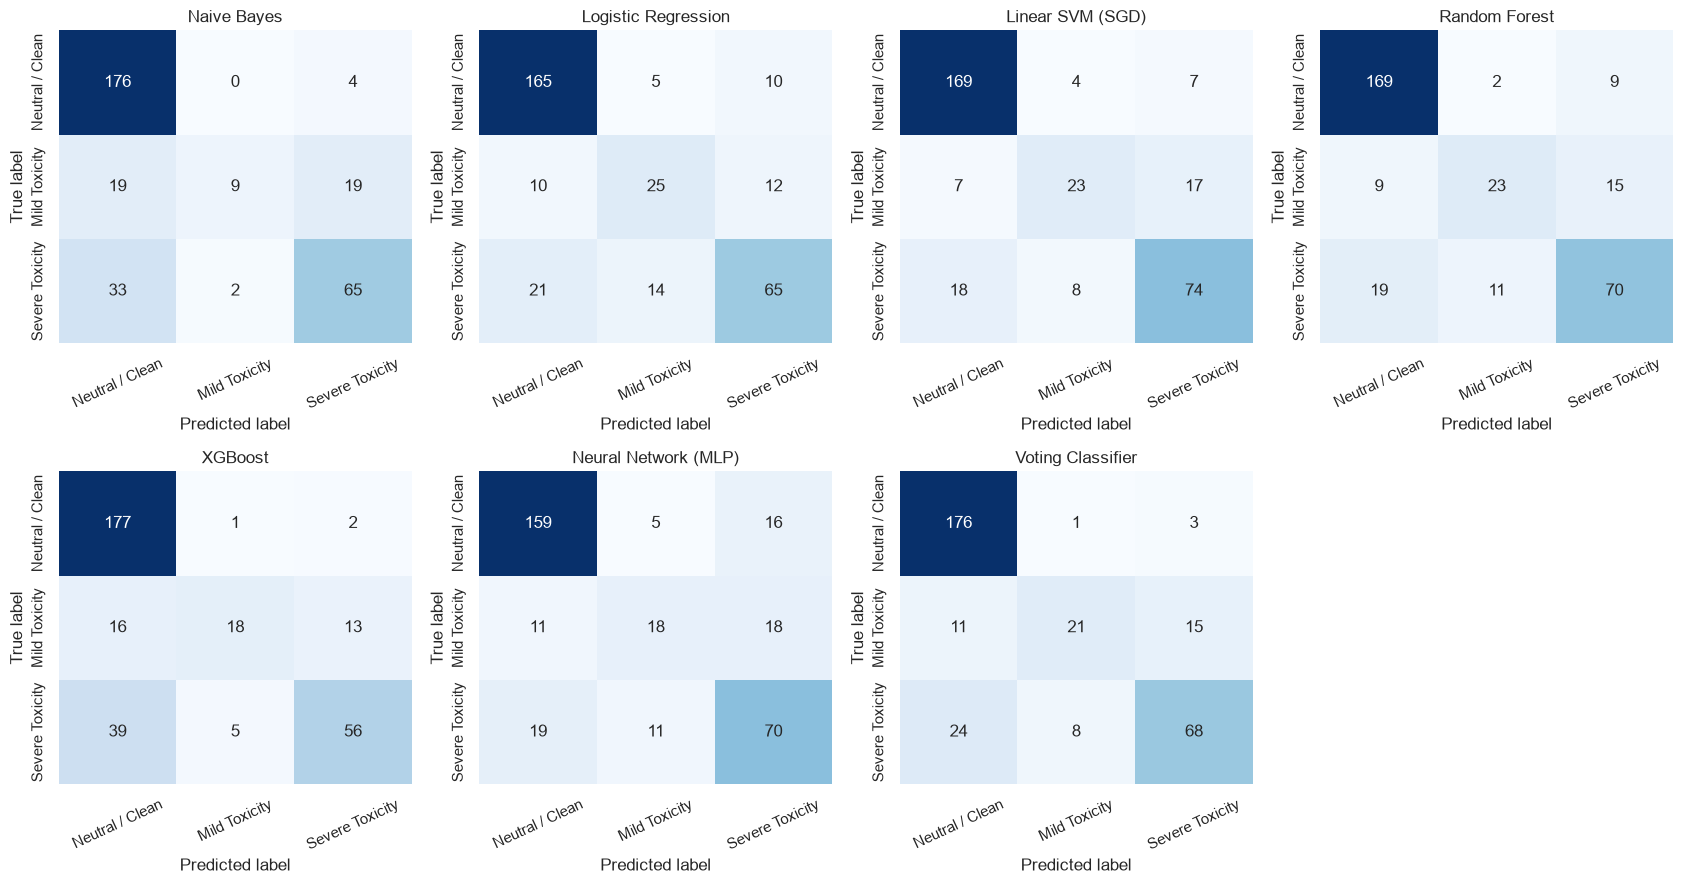

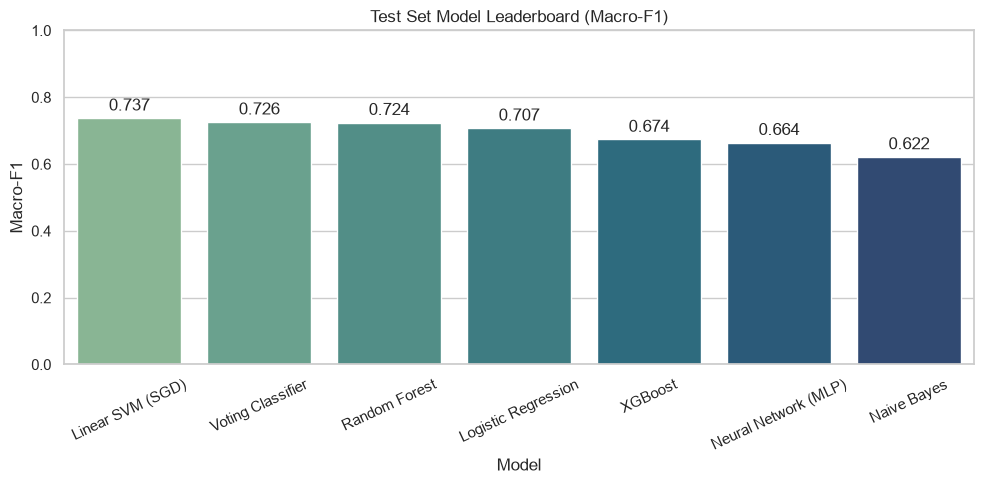

Saved Linear SVM (SGD) and its TF-IDF vectorizer to C:\Users\dkshp\OneDrive\Desktop\guardian_ai.worktrees\guardian-ai-repo-restructure-notebook\models\champion_model.pkl


In [17]:
# I read the class-by-class mistakes here, not just the overall score.

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for ax, (model_name, y_pred) in zip(axes.flat, test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=[CLASS_NAMES[i] for i in [0, 1, 2]],
        yticklabels=[CLASS_NAMES[i] for i in [0, 1, 2]],
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.tick_params(axis="x", rotation=25)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=leaderboard_df, x="Model", y="Macro-F1", hue="Model", palette="crest", legend=False)
ax.set_title("Test Set Model Leaderboard (Macro-F1)")
ax.set_xlabel("Model")
ax.set_ylabel("Macro-F1")
ax.tick_params(axis="x", rotation=25)
ax.set_ylim(0, 1)
for patch in ax.patches:
    ax.annotate(
        f"{patch.get_height():.3f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center", va="bottom", xytext=(0, 3), textcoords="offset points",
    )
plt.tight_layout()
plt.show()

champion_name = leaderboard_df.loc[0, "Model"]
champion_model = trained_models[champion_name]
models_dir = PROJECT_ROOT / "models"
models_dir.mkdir(parents=True, exist_ok=True)
champion_path = models_dir / "champion_model.pkl"
joblib.dump(
    {"model": champion_model, "vectorizer": vectorizer, "model_name": champion_name},
    champion_path,
)
print(f"Saved {champion_name} and its TF-IDF vectorizer to {champion_path}")


## Section 7: Step 7: Feature Interpretability

I look at the Logistic Regression weights for Severe Toxicity, class 2. Before plotting, I mask token text so profanity is not shown in full.


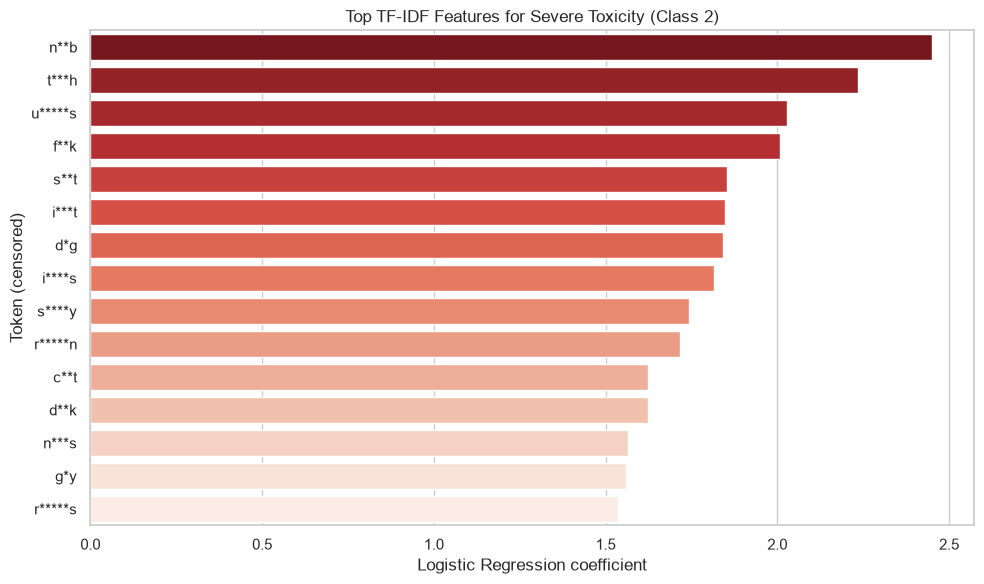

,Token (censored),Logistic Regression coefficient
0,n**b,2.450121
1,t***h,2.234132
2,u*****s,2.029178
3,f**k,2.007246
4,s**t,1.853741
5,i***t,1.847797
6,d*g,1.840432
7,i****s,1.815321
8,s****y,1.744293
9,r*****n,1.716069


In [18]:
# I check the class-2 Logistic Regression weights and censor the displayed tokens.

def censor_word(word):
    """Mask internal characters so sensitive profanity is not rendered in full."""
    return word if len(word) <= 2 else word[0] + "*" * (len(word) - 2) + word[-1]


log_reg_model = trained_models["Logistic Regression"]
class_two_index = list(log_reg_model.classes_).index(2)
class_two_coefficients = log_reg_model.coef_[class_two_index]
feature_names = vectorizer.get_feature_names_out()
top_positive_indices = np.argsort(class_two_coefficients)[-15:][::-1]
top_tokens = [feature_names[i] for i in top_positive_indices]
top_scores = class_two_coefficients[top_positive_indices]
interpretability_df = pd.DataFrame({
    "Token (censored)": [censor_word(token) for token in top_tokens],
    "Logistic Regression coefficient": top_scores,
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=interpretability_df, x="Logistic Regression coefficient",
    y="Token (censored)", hue="Token (censored)", palette="Reds_r", legend=False
)
plt.title("Top TF-IDF Features for Severe Toxicity (Class 2)")
plt.tight_layout()
plt.show()
display(interpretability_df)


## Section 8: Knowledge Base and ChromaDB Vector Store

I bring the policy wording across from `rag_llm/safety_policies.py` and keep that copy inside the notebook. The separate slang notes add esports context for `kys`, `diff`, `gap`, `gg ez`, and `ff at 15`; no `rag_llm` import is needed when this notebook runs.


In [19]:
# I keep the actual project policies here, so the notebook owns its own rule set.
import json
import re
import warnings

SAFETY_RULES = [{'rule_id': 'RULE_101', 'category': 'Gender Harassment & Sexism', 'content': "RULE 101: Targeted Gender Harassment, Misogyny & Sexism.\n• Prohibited: Any derogatory, degrading, or hostile remarks directed at female, non-binary, or LGBTQ+ players. This includes stereotyped insults ('go back to the kitchen', 'make me a sandwich'), unwanted sexual remarks, harassment triggered upon hearing a player's voice in mic chat, or claiming women/gender minorities cannot play games.\n• Banter Exception: General gameplay criticism (e.g., 'that was a bad play') is allowed ONLY if it does not target gender or identity.\n• Severity: HIGH. Recommended Action: Temporary Ban"}, {'rule_id': 'RULE_102', 'category': 'Child Safety & Predatory Grooming', 'content': "RULE 102: Child Exploitation, Grooming & Private Information Solicitation.\n• Prohibited: Asking self-identified minors (or players indicating under-18 age/schooling) for real-world personal details. This includes requesting real names, exact age, physical address/city/school, phone numbers, or asking to move the conversation to private off-platform apps (e.g., 'add me on Discord', 'snap me'). Explicit grooming or sexualized comments toward minors are zero-tolerance.\n• Severity: CRITICAL / ZERO-TOLERANCE. Recommended Action: Permanent Permaban & Escalate"}, {'rule_id': 'RULE_103', 'category': 'Evasive Toxicity, Self-Harm & Leetspeak Bypasses', 'content': "RULE 103: Filter Evasion, Self-Harm Encouragement & Severe Abuse.\n• Prohibited: Using special characters, numbers, misspellings, or leetspeak to bypass chat filters while encouraging suicide or self-harm (e.g., 'g0 k1ll ur53lf', 'un1st4ll l1f3', 'K-Y-S', 'd1e trash'). Also prohibits extreme death threats or severe self-harm encouragement.\n• Filter Evasion Clause: Obfuscation of prohibited terms does NOT grant immunity and is treated as an intentional violation.\n• Severity: CRITICAL. Recommended Action: Permanent Permaban & Escalate"}, {'rule_id': 'RULE_104', 'category': 'Targeted Bullying & Multi-Turn Harassment', 'content': "RULE 104: Multi-Turn Harassment & Targeted Stalking/Griefing.\n• Prohibited: Repeatedly sending hostile, insulting, or belittling messages across multiple turns aimed at a single player to ruin their experience, force them to quit, or incite the rest of the lobby against them (e.g., continuous target harassment over 3+ messages).\n• Banter vs. Bullying: One-off competitive frustration ('c'mon shoot better') is BANTER. Persistently following a player with insults across chat is BULLYING.\n• Severity: MEDIUM-HIGH. Recommended Action: Temporary Ban"}, {'rule_id': 'RULE_105', 'category': 'Clean Competitive Banter (Allowed)', 'content': "RULE 105: Permissible Competitive Gaming Banter.\n• Allowed: Normal game-related callouts, friendly rivalry, emotional reactions to gameplay, and light competitive teasing (e.g., 'nice try', 'too easy', 'diff', 'clutch or kick', 'my team is sleeping').\n• Boundary: Banter MUST remain strictly focused on gameplay skills and MUST NOT cross into protected identity attacks, personal details, death threats, or relentless individual targeting.\n• Severity: NONE (Clean Play). Recommended Action: No Action"}, {'rule_id': 'RULE_106', 'category': 'General Vulgarity & Profanity Outbursts', 'content': "RULE 106: General Toxicity, Excessive Vulgarity & Aggressive Profanity.\n• Prohibited: Aggressive outbursts, excessive swearing, telling other players to shut up or fuck off in a hostile tone (e.g., 'shut the fuck up', 'get out of here trash', screaming aggressively in text).\n• Distinction: General non-targeted profanity or rage outbursts. Evaluated based on hostility level.\n• Severity: LOW to MEDIUM. Recommended Action: Lobby Mute"}, {'rule_id': 'RULE_107', 'category': 'Hate Speech & Identity Discrimination', 'content': 'RULE 107: Hate Speech, Racial Slurs & Bigotry.\n• Prohibited: Promoting hatred, discrimination, or using slurs based on race, ethnicity, religion, nationality, disability, or sexual orientation.\n• Zero-Tolerance: Uses of slurs or derogatory identity-focused slurs are strictly forbidden regardless of context.\n• Severity: HIGH to CRITICAL. Recommended Action: Permanent Permaban & Escalate'}, {'rule_id': 'RULE_108', 'category': 'Real-World Threats & Doxxing', 'content': "RULE 108: Real-World Threats, Violence & Doxxing.\n• Prohibited: Threatening real-world physical violence, swatting, or leaking/publishing another player's private personal information (IP address, real name, home address, phone number).\n• Severity: CRITICAL. Recommended Action: Permanent Permaban & Escalate"}, {'rule_id': 'RULE_109', 'category': 'Spam & Commercial Scams', 'content': 'RULE 109: Commercial Spam, Phishing & Account Scams.\n• Prohibited: Repeatedly spamming chat lines, advertising external commercial sites, free skin/currency scams, phishing links, or boosting services.\n• Severity: LOW to MEDIUM. Recommended Action: Lobby Mute'}]

# I add a short lookup for common lobby slang without changing the policy text above.
GAMING_CONTEXT_RULES = [
    {
        "rule_id": "GAMING_KYS",
        "category": "Evasive self-harm encouragement",
        "content": "In gaming chat, kys means kill yourself. Treat it as severe self-harm encouragement, including spaced or punctuated forms such as k.y.s.",
        "label": 2,
    },
    {
        "rule_id": "GAMING_DIFF_GAP",
        "category": "Skill comparison",
        "content": "Diff and gap usually compare player or team skill. A gameplay-focused insult is mild toxicity, not automatically hate speech.",
        "label": 1,
    },
    {
        "rule_id": "GAMING_GG_EZ",
        "category": "Taunt",
        "content": "GG ez is a taunt or mild toxicity in ordinary gaming context. Escalate only when the surrounding message crosses a more serious rule.",
        "label": 1,
    },
    {
        "rule_id": "GAMING_FF_15",
        "category": "Forfeit call",
        "content": "FF at 15 is a request to forfeit. Treat it as clean strategy unless it is paired with hostile personal insults.",
        "label": 0,
    },
]

# I give every stored item a consistent shape before building the vector index.
POLICY_LABELS = {
    "RULE_101": 2, "RULE_102": 2, "RULE_103": 2, "RULE_104": 1,
    "RULE_105": 0, "RULE_106": 1, "RULE_107": 2, "RULE_108": 2,
    "RULE_109": 1,
}
RULE_ENTRIES = [
    {
        "rule_id": rule["rule_id"],
        "category": rule["category"],
        "content": rule["content"],
        "label": POLICY_LABELS[rule["rule_id"]],
    }
    for rule in SAFETY_RULES
] + GAMING_CONTEXT_RULES

# I use the same compact sentence model as the modular vector-store example.
vector_collection = None
sentence_encoder = None
try:
    import chromadb
    from sentence_transformers import SentenceTransformer

    sentence_encoder = SentenceTransformer("all-MiniLM-L6-v2")
    chroma_client = chromadb.Client()
    vector_collection = chroma_client.create_collection(
        name="esports_safety_rules"
    )
    rule_embeddings = sentence_encoder.encode(
        [rule["content"] for rule in RULE_ENTRIES],
        convert_to_numpy=True,
    ).tolist()
    vector_collection.add(
        ids=[rule["rule_id"] for rule in RULE_ENTRIES],
        documents=[rule["content"] for rule in RULE_ENTRIES],
        embeddings=rule_embeddings,
        metadatas=[
            {
                "rule_id": rule["rule_id"],
                "category": rule["category"],
                "label": rule["label"],
            }
            for rule in RULE_ENTRIES
        ],
    )
    print(f"Indexed {len(RULE_ENTRIES)} policies and slang notes in memory.")
except Exception as exc:
    warnings.warn(
        f"Vector setup is unavailable ({type(exc).__name__}). "
        "I will use the visible local rule matcher instead.",
        RuntimeWarning,
    )


def normalize_chat(text):
    """I normalize punctuation and common number swaps before checking slang."""
    text = re.sub(r"[^a-z0-9]+", " ", str(text).lower()).strip()
    return text.translate(str.maketrans({"0": "o", "1": "i", "3": "e", "4": "a", "5": "s", "7": "t"}))


def local_rule_matches(message, context=(), top_k=2):
    """I keep clear policy cues ahead of the general word-overlap fallback."""
    normalized = normalize_chat(message)
    compact = re.sub(r"[^a-z0-9]", "", str(message).lower())
    context_text = normalize_chat(" ".join(context))
    prioritized = []

    if "kys" in compact or re.search(r"kill yourself|end yourself|go die|uninstall life", normalized):
        prioritized = ["RULE_103", "GAMING_KYS"]
    elif re.search(r"school|discord|snapchat|address|phone number", normalized) and re.search(r"minor|\\b10\\b|\\b11\\b|\\b12\\b|\\b13\\b|\\b14\\b|\\b15\\b|\\b16\\b|\\b17\\b", context_text + " " + normalized):
        prioritized = ["RULE_102"]
    elif re.search(r"girl|woman|women|kitchen|sandwich", normalized):
        prioritized = ["RULE_101"]
    elif re.search(r"threaten|swat|home address|ip address|real name", normalized):
        prioritized = ["RULE_108"]
    elif re.search(r"cancer|subhuman", normalized):
        prioritized = ["RULE_107", "RULE_103"]
    elif re.search(r"\\bgg ez\\b", normalized):
        prioritized = ["GAMING_GG_EZ", "RULE_105"]
    elif re.search(r"\\bdiff\\b|\\bgap\\b", normalized):
        prioritized = ["GAMING_DIFF_GAP", "RULE_105"]
    elif re.search(r"\\bff at 15\\b", normalized):
        prioritized = ["GAMING_FF_15", "RULE_105"]
    elif re.search(r"trash|uninstall|noob|fuck|bitch", normalized):
        prioritized = ["RULE_106", "RULE_105"]

    by_id = {rule["rule_id"]: rule for rule in RULE_ENTRIES}
    selected = [by_id[rule_id] for rule_id in prioritized if rule_id in by_id]
    if vector_collection is not None and sentence_encoder is not None:
        try:
            query_embedding = sentence_encoder.encode(
                [message], convert_to_numpy=True
            ).tolist()
            result = vector_collection.query(
                query_embeddings=query_embedding, n_results=top_k
            )
            ids = result.get("ids", [[]])[0]
            vector_matches = [by_id[rule_id] for rule_id in ids if rule_id in by_id]
            for match in vector_matches:
                if match["rule_id"] not in {rule["rule_id"] for rule in selected}:
                    selected.append(match)
        except Exception as exc:
            warnings.warn(
                f"Vector lookup failed ({type(exc).__name__}); using local rule matching.",
                RuntimeWarning,
            )

    if not selected:
        words = set(normalized.split())
        ranked = []
        for rule in RULE_ENTRIES:
            rule_words = set(normalize_chat(rule["content"]).split())
            score = len(words & rule_words) / max(1, len(words | rule_words))
            ranked.append((score, rule))
        ranked.sort(key=lambda row: row[0], reverse=True)
        selected = [rule for _, rule in ranked[:top_k]]
    return selected[:top_k] or [by_id["RULE_105"]]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

C:\Users\dkshp\AppData\Local\Temp\ipykernel_19676\468879249.py:83: RuntimeWarning: Vector setup is unavailable (InternalError). I will use the visible local rule matcher instead.
  warnings.warn(


## Section 9: Context Buffer and Gemini Orchestrator

I keep the last five chat messages, retrieve two relevant rules, and send both to Gemini with the same audit fields used by the modular project. The key can be named `GOOGLE_API_KEY` or `GEMINI_API_KEY`. A failed API call is shown as a warning and falls back to the local rule audit.


In [20]:
# I use the same audit fields and policy guidance as prompts.py, but keep them in this notebook.
import json
import os
import time
import warnings
from pathlib import Path

from pydantic import BaseModel, Field
from typing import Literal

# I let either key name work, and I never print or display the key itself.
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    print("python-dotenv is missing; I will check the process environment only.")

GOOGLE_API_KEY = (
    os.getenv("GOOGLE_API_KEY", "").strip()
    or os.getenv("GEMINI_API_KEY", "").strip()
)
GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.8-flash")
gemini_client = None
genai_types = None
try:
    from google import genai
    from google.genai import types as genai_types
    if GOOGLE_API_KEY:
        gemini_client = genai.Client(api_key=GOOGLE_API_KEY)
        print(f"Gemini key found. I will use {GEMINI_MODEL}; the key stays hidden.")
    else:
        print("No Gemini key found. The local rule audit remains available.")
except ImportError as exc:
    warnings.warn(
        f"google-genai is unavailable ({type(exc).__name__}). "
        "I will use the local rule audit.",
        RuntimeWarning,
    )


class ChatBuffer:
    """I keep the same rolling sender/message history as chat_buffer.py."""
    def __init__(self, max_history=5):
        self.max_history = max_history
        self.history = []

    def add_message(self, sender, text):
        self.history.append({"sender": str(sender), "text": str(text)})
        self.history = self.history[-self.max_history:]

    def get_formatted_context(self):
        if not self.history:
            return "No prior chat context."
        return "\n".join(
            f"[{index}] {item['sender']}: {item['text']}"
            for index, item in enumerate(self.history, start=1)
        )

    def clear(self):
        self.history.clear()


class SafetyAuditResult(BaseModel):
    # I keep the structured fields from prompts.py and add the benchmark label.
    is_flagged: bool = Field(description="Whether this message violates policy.")
    severity: Literal["NONE", "LOW", "MEDIUM", "HIGH", "CRITICAL"]
    violated_rule: str
    target_group: Literal["Kids", "Women / Gender Minorities", "General Lobby", "None"]
    summary_reasoning: str
    recommended_action: Literal[
        "No Action", "Lobby Mute", "Temporary Ban", "Permanent Permaban & Escalate"
    ]
    predicted_label: Literal[0, 1, 2]
    confidence: float
    applied_rule_id: str
    reasoning: str


SYSTEM_INSTRUCTION = """
You are Guardian AI, the esports trust and safety auditor.
Use the retrieved project policies and recent chat context. Distinguish gameplay banter
from harassment. Decode leetspeak and punctuation used to hide self-harm encouragement.
Treat requests for a minor's school, address, phone, or off-platform contact as a child
safety risk when the context indicates that the player is a minor. Repeated targeting
is bullying; ordinary skill callouts are not automatically a violation.

Return strict JSON only with the exact fields and types in SafetyAuditResult:
is_flagged, severity, violated_rule, target_group, summary_reasoning,
recommended_action, predicted_label (0 clean, 1 mild, 2 severe),
confidence (0.0 to 1.0), applied_rule_id, and reasoning.
"""


def local_audit_result(message, matched_rules, history):
    """I have a local answer ready when Gemini is missing or returns an error."""
    normalized = normalize_chat(message)
    context = normalize_chat(" ".join(
        item["text"] if isinstance(item, dict) else str(item)
        for item in history
    ))
    compact = re.sub(r"[^a-z0-9]", "", str(message).lower())
    rule_ids = {rule["rule_id"] for rule in matched_rules}

    if "kys" in compact or re.search(r"kill yourself|end yourself|go die|uninstall life", normalized):
        label, rule_id, group = 2, "RULE_103", "General Lobby"
        reasoning = "The message encourages self-harm or uses an evasive form of that message."
    elif re.search(r"school|discord|snapchat|address|phone number", normalized) and re.search(
        r"minor|\b10\b|\b11\b|\b12\b|\b13\b|\b14\b|\b15\b|\b16\b|\b17\b",
        context + " " + normalized,
    ):
        label, rule_id, group = 2, "RULE_102", "Kids"
        reasoning = "The chat context suggests a minor and the message asks for private or off-platform contact."
    elif re.search(r"girl|woman|women|kitchen|sandwich", normalized):
        label, rule_id, group = 2, "RULE_101", "Women / Gender Minorities"
        reasoning = "The message targets a player using gendered harassment."
    elif re.search(r"threaten|swat|home address|ip address|real name", normalized):
        label, rule_id, group = 2, "RULE_108", "General Lobby"
        reasoning = "The message contains a real-world threat or private-information risk."
    elif re.search(r"cancer|subhuman", normalized):
        label, rule_id, group = 2, "RULE_107", "General Lobby"
        reasoning = "The message contains severe abuse or identity-targeted language."
    elif re.search(r"\bgg ez\b", normalized):
        label, rule_id, group = 1, "GAMING_GG_EZ", "General Lobby"
        reasoning = "GG ez is a gameplay taunt, so I mark it as mild toxicity."
    elif re.search(r"\bdiff\b|\bgap\b", normalized):
        label, rule_id, group = 1, "GAMING_DIFF_GAP", "General Lobby"
        reasoning = "Diff or gap is used as a gameplay skill insult, so I mark it as mild toxicity."
    elif re.search(r"\bff at 15\b", normalized):
        label, rule_id, group = (1, "RULE_106", "General Lobby") if re.search(
            r"useless|trash|idiot|bad", normalized
        ) else (0, "GAMING_FF_15", "None")
        reasoning = "I read ff at 15 as a forfeit call and check whether it is paired with an insult."
    elif re.search(r"trash|uninstall|noob|fuck|bitch|useless", normalized):
        label, rule_id, group = 1, "RULE_106", "General Lobby"
        reasoning = "The message uses a hostile insult, which fits the general toxicity rule."
    else:
        label, rule_id, group = 0, "RULE_105", "None"
        reasoning = "I do not see a clear policy violation; this reads as ordinary gameplay chat."

    # I keep the selected rule valid even if the vector result ranked another policy first.
    if rule_id not in {rule["rule_id"] for rule in RULE_ENTRIES}:
        rule_id = next(iter(rule_ids), "RULE_105")
    severity = {0: "NONE", 1: "MEDIUM", 2: "CRITICAL"}[label]
    action = {
        0: "No Action",
        1: "Lobby Mute",
        2: "Permanent Permaban & Escalate",
    }[label]
    violated = next(
        (rule for rule in RULE_ENTRIES if rule["rule_id"] == rule_id), None
    )
    return {
        "is_flagged": label > 0,
        "severity": severity,
        "violated_rule": (
            f"{rule_id}: {violated['category']}" if label and violated else "None"
        ),
        "target_group": group,
        "summary_reasoning": reasoning,
        "recommended_action": action,
        "predicted_label": label,
        "confidence": 0.70,
        "applied_rule_id": rule_id,
        "reasoning": reasoning,
    }


class GuardianEngine:
    """I join the rule search, rolling context, and Gemini response in one place."""
    def __init__(self, max_history=5):
        self.buffer = ChatBuffer(max_history=max_history)
        self.client = gemini_client

    def reset_chat(self):
        self.buffer.clear()

    def audit_message(self, sender, text):
        # I retrieve two rules before building the prompt, just like vector_db.py.
        matched_rules = local_rule_matches(
            text, context=self.buffer.history, top_k=2
        )
        prior_context = self.buffer.get_formatted_context()
        self.buffer.add_message(sender, text)
        fallback = local_audit_result(
            text, matched_rules, self.buffer.history[:-1]
        )
        if self.client is None:
            return fallback

        rules_text = "\n\n".join(rule["content"] for rule in matched_rules)
        prompt = (
            "=== RETRIEVED COMMUNITY POLICY ===\n"
            f"{rules_text}\n\n"
            "=== RECENT CHAT TRANSCRIPT ===\n"
            f"{prior_context}\n\n"
            "=== TARGET MESSAGE TO AUDIT ===\n"
            f"{sender}: {text}\n\n"
            "Return one JSON audit using the required schema."
        )
        try:
            response = self.client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
                config=genai_types.GenerateContentConfig(
                    system_instruction=SYSTEM_INSTRUCTION,
                    response_mime_type="application/json",
                    response_schema=SafetyAuditResult,
                    temperature=0.1,
                ),
            )
            # I validate the model response before using it in the lobby view.
            result = SafetyAuditResult.model_validate_json(response.text).model_dump()
            if result["applied_rule_id"] not in {
                rule["rule_id"] for rule in RULE_ENTRIES
            }:
                result["applied_rule_id"] = matched_rules[0]["rule_id"]
            return result
        except Exception as exc:
            warnings.warn(
                f"Gemini audit failed ({type(exc).__name__}); I am showing the "
                "local policy result for this message.",
                RuntimeWarning,
            )
            return fallback


# I expose key status without printing the key or making a surprise API request.
print("RAG audit engine is ready. Gemini configured:", gemini_client is not None)
guardian_engine = GuardianEngine(max_history=5)


Gemini key found. I will use gemini-3.8-flash; the key stays hidden.
RAG audit engine is ready. Gemini configured: True


## Section 10: Dual-Arm Benchmark

I compare the two arms on twelve examples only: four clean, four mild, and four severe. Each Gemini request is separated by 1.5 seconds. I do not send the full test split to the API.


In [21]:
# I keep this assignment check at twelve messages so Gemini calls stay limited.
benchmark_samples = [
    {"text": "b rush b site now", "true_label": 0},
    {"text": "gg wp good play team", "true_label": 0},
    {"text": "hold mid and rotate after the plant", "true_label": 0},
    {"text": "ff at 15, we can regroup next round", "true_label": 0},
    {"text": "mid diff trash team gg ez", "true_label": 1},
    {"text": "uninstall the game zero impact", "true_label": 1},
    {"text": "you lost the lane, huge gap", "true_label": 1},
    {"text": "ff at 15, you are all useless", "true_label": 1},
    {"text": "kys go end yourself", "true_label": 2},
    {"text": "k.y.s trash subhuman", "true_label": 2},
    {"text": "get cancer and die", "true_label": 2},
    {"text": "go kill yourself, you worthless player", "true_label": 2},
]
assert len(benchmark_samples) == 12
assert [sum(row["true_label"] == label for row in benchmark_samples)
        for label in (0, 1, 2)] == [4, 4, 4]

# I also guard against a notebook kernel that still has the older string-only matcher loaded.
if not getattr(local_rule_matches, "_guardian_context_compat", False):
    _previous_rule_matcher = local_rule_matches

    def _context_as_text(messages):
        if messages is None:
            return ""
        if isinstance(messages, str):
            return messages
        pieces = []
        for item in messages:
            if isinstance(item, dict):
                pieces.extend((str(item.get("sender", "")), str(item.get("text", ""))))
            elif isinstance(item, (tuple, list)):
                pieces.extend(str(part) for part in item)
            else:
                pieces.append(str(item))
        return " ".join(piece for piece in pieces if piece)

    def _context_compatible_rule_matcher(message, context=(), top_k=2):
        # I pass the old matcher plain text so it cannot try to join dictionaries.
        return _previous_rule_matcher(
            message,
            context=[_context_as_text(context)],
            top_k=top_k,
        )

    _context_compatible_rule_matcher._guardian_context_compat = True
    local_rule_matches = _context_compatible_rule_matcher


# I load the champion saved above and reuse its paired vectorizer for every chat.
champion_artifact = joblib.load(champion_path)


def predict_classical(message):
    features = champion_artifact["vectorizer"].transform([message])
    model = champion_artifact["model"]
    label = int(model.predict(features)[0])
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba(features)[0]))
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(features)).reshape(-1)
        shifted = np.exp(scores - np.max(scores))
        confidence = float(np.max(shifted / shifted.sum()))
    else:
        confidence = float("nan")
    return label, confidence


# I time each arm separately and keep the requested one-and-a-half-second pause.
guardian_engine.reset_chat()
benchmark_rows = []
for index, sample in enumerate(benchmark_samples):
    message = sample["text"]
    ml_start = time.perf_counter()
    ml_label, ml_confidence = predict_classical(message)
    ml_latency = (time.perf_counter() - ml_start) * 1000

    rag_start = time.perf_counter()
    rag_result = guardian_engine.audit_message("BenchmarkPlayer", message)
    rag_latency = (time.perf_counter() - rag_start) * 1000
    benchmark_rows.append({
        "Chat Message": message,
        "True Label": sample["true_label"],
        "Classical ML Pred": ml_label,
        "RAG LLM Pred": rag_result["predicted_label"],
        "RAG Reasoning": rag_result["reasoning"],
        "Latency (ms)": f"ML {ml_latency:.2f} / RAG {rag_latency:.2f}",
    })
    if index < len(benchmark_samples) - 1:
        time.sleep(1.5)

# I put the side-by-side decisions first, then score both arms on the same labels.
benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)
benchmark_metrics = pd.DataFrame([
    {
        "Arm": "Classical ML",
        "Accuracy": accuracy_score(
            benchmark_df["True Label"], benchmark_df["Classical ML Pred"]
        ),
        "Macro-F1": f1_score(
            benchmark_df["True Label"], benchmark_df["Classical ML Pred"],
            average="macro", zero_division=0,
        ),
    },
    {
        "Arm": "RAG LLM or local fallback",
        "Accuracy": accuracy_score(
            benchmark_df["True Label"], benchmark_df["RAG LLM Pred"]
        ),
        "Macro-F1": f1_score(
            benchmark_df["True Label"], benchmark_df["RAG LLM Pred"],
            average="macro", zero_division=0,
        ),
    },
])
display(benchmark_metrics.style.format({"Accuracy": "{:.3f}", "Macro-F1": "{:.3f}"}))

# I use the observed rows in the note instead of claiming either model always wins.
ml_evasive_misses = benchmark_df[
    (benchmark_df["True Label"] == 2)
    & (benchmark_df["Classical ML Pred"] != 2)
]["Chat Message"].tolist()
rag_severe_hits = benchmark_df[
    (benchmark_df["True Label"] == 2)
    & (benchmark_df["RAG LLM Pred"] == 2)
]["Chat Message"].tolist()
display(Markdown(
    "**What I notice:** The TF-IDF arm can miss evasive spelling or sarcasm when "
    "the wording is unlike its training examples. The RAG arm can use the retrieved "
    "project rules and slang notes to make that context clearer. I still check the "
    "actual results rather than assume the LLM is always right.\\n\\n"
    f"- Severe examples missed by Classical ML: {ml_evasive_misses or 'none in this run.'}\\n"
    f"- Severe examples caught by the RAG arm: {rag_severe_hits or 'none in this run.'}\\n\\n"
    "These twelve curated examples are a classroom comparison, not a population-level estimate."
))


C:\Users\dkshp\AppData\Local\Temp\ipykernel_19676\1061559380.py:219: RuntimeWarning: Gemini audit failed (ValidationError); I am showing the local policy result for this message.
  warnings.warn(


,Chat Message,True Label,Classical ML Pred,RAG LLM Pred,RAG Reasoning,Latency (ms)
0,b rush b site now,0,0,0,I do not see a clear policy violation; this re...,ML 1.32 / RAG 2.23
1,gg wp good play team,0,0,0,I do not see a clear policy violation; this re...,ML 1.45 / RAG 1.79
2,hold mid and rotate after the plant,0,0,0,I do not see a clear policy violation; this re...,ML 1.91 / RAG 1.84
3,"ff at 15, we can regroup next round",0,0,0,I do not see a clear policy violation; this re...,ML 1.41 / RAG 1.76
4,mid diff trash team gg ez,1,2,1,"GG ez is a gameplay taunt, so I mark it as mil...",ML 1.42 / RAG 1.49
5,uninstall the game zero impact,1,0,1,"The message uses a hostile insult, which fits ...",ML 1.44 / RAG 1.39
6,"you lost the lane, huge gap",1,0,1,Diff or gap is used as a gameplay skill insult...,ML 1.60 / RAG 2.07
7,"ff at 15, you are all useless",1,2,1,"The message uses a hostile insult, which fits ...",ML 1.36 / RAG 1.79
8,kys go end yourself,2,2,2,The message encourages self-harm or uses an ev...,ML 2.01 / RAG 2.21
9,k.y.s trash subhuman,2,2,2,The message encourages self-harm or uses an ev...,ML 1.39 / RAG 1.72


,Arm,Accuracy,Macro-F1
0,Classical ML,0.583,0.465
1,RAG LLM or local fallback,1.000,1.000


**What I notice:** The TF-IDF arm can miss evasive spelling or sarcasm when the wording is unlike its training examples. The RAG arm can use the retrieved project rules and slang notes to make that context clearer. I still check the actual results rather than assume the LLM is always right.\n\n- Severe examples missed by Classical ML: ['go kill yourself, you worthless player']\n- Severe examples caught by the RAG arm: ['kys go end yourself', 'k.y.s trash subhuman', 'get cancer and die', 'go kill yourself, you worthless player']\n\nThese twelve curated examples are a classroom comparison, not a population-level estimate.

## Section 11: Live Lobby Audit

I use a small notebook lobby view inspired by the Streamlit feed and the CLI scenario checks. Load a quick message, choose a player, and send it to see the rolling chat, classical score, matched rule, and moderation reasoning together.


In [22]:
# I make the final cell feel like a small live lobby, not a dataframe form.
import html
from datetime import datetime

try:
    import ipywidgets as widgets
    from IPython.display import HTML, clear_output, display

    lobby_events = []
    quick_messages = {
        "Clean banter": ("PlayerOne", "Nice shot mate!"),
        "Leetspeak": ("SaltyPlayer", "g0 k1ll ur53lf un1st4ll l1f3"),
        "Gender harassment": (
            "ToxikUser",
            "Is that a girl on mic? Go back to the kitchen and make me a sandwich.",
        ),
        "Child safety": (
            "PredatorX",
            "Cool, what school do you go to? Add me on Snapchat.",
        ),
    }
    active_sample = {"sender": "", "message": ""}

    # I use a dark terminal-like panel so the feed is easy to scan while testing.
    live_output = widgets.Output(
        layout=widgets.Layout(
            border="1px solid #334155",
            padding="12px",
            width="100%",
        )
    )
    sender_input = widgets.Text(
        value="Player_1",
        description="Player",
        placeholder="Player name",
        layout=widgets.Layout(width="32%"),
    )
    message_input = widgets.Textarea(
        placeholder="Type a chat message, then send it for an audit...",
        description="Message",
        layout=widgets.Layout(width="100%", height="74px"),
    )
    send_button = widgets.Button(
        description="Send and audit",
        button_style="primary",
        icon="paper-plane",
    )
    reset_button = widgets.Button(
        description="Reset lobby",
        button_style="warning",
        icon="refresh",
    )
    sample_buttons = [
        widgets.Button(description=name, tooltip=text)
        for name, (_, text) in quick_messages.items()
    ]

    def draw_lobby(error_message=None):
        # I escape player text before putting it into the HTML feed.
        with live_output:
            clear_output(wait=True)
            if not lobby_events:
                feed = (
                    "<div class='empty'>Lobby is quiet. Load a sample or send "
                    "the first message.</div>"
                )
                latest = (
                    "<div class='empty'>The audit panel will show both model "
                    "results after a message is sent.</div>"
                )
            else:
                cards = []
                for event in lobby_events[-12:]:
                    audit = event["audit"]
                    flagged = audit["is_flagged"]
                    badge = "FLAGGED" if flagged else "CLEAN"
                    color = "#f87171" if flagged else "#4ade80"
                    cards.append(
                        "<div class='chat-row'>"
                        f"<span class='time'>{html.escape(event['time'])}</span> "
                        f"<b>{html.escape(event['sender'])}</b>: "
                        f"{html.escape(event['message'])}<br>"
                        f"<span style='color:{color}'>[{badge} / "
                        f"{html.escape(audit['severity'])}]</span> "
                        f"<span class='muted'>{html.escape(audit['violated_rule'])}</span>"
                        "</div>"
                    )
                feed = "".join(cards)
                current = lobby_events[-1]
                audit = current["audit"]
                latest = (
                    "<div class='audit-card'>"
                    f"<div class='status'>{'VIOLATION' if audit['is_flagged'] else 'CLEAN PLAY'}"
                    f" <span class='muted'>/ {html.escape(audit['severity'])}</span></div>"
                    f"<p><b>Classical ML:</b> {current['ml_label']} "
                    f"({html.escape(CLASS_NAMES[current['ml_label']])}), "
                    f"score {current['ml_confidence']:.3f}, "
                    f"{current['ml_latency']:.2f} ms</p>"
                    f"<p><b>RAG / Gemini:</b> {audit['predicted_label']} "
                    f"({html.escape(CLASS_NAMES[audit['predicted_label']])}), "
                    f"{current['rag_latency']:.2f} ms</p>"
                    f"<p><b>Applied rule:</b> "
                    f"<code>{html.escape(audit['applied_rule_id'])}</code></p>"
                    f"<p><b>Rule:</b> {html.escape(audit['violated_rule'])}</p>"
                    f"<p><b>Reasoning:</b> "
                    f"{html.escape(audit['summary_reasoning'])}</p>"
                    f"<p><b>Action:</b> {html.escape(audit['recommended_action'])}</p>"
                    f"<p><b>Recent context:</b><br><code>"
                    f"{html.escape(guardian_engine.buffer.get_formatted_context())}"
                    "</code></p></div>"
                )
            error = (
                f"<div class='error'>{html.escape(error_message)}</div>"
                if error_message else ""
            )
            display(HTML(
                "<style>"
                ".guardian{font-family:Segoe UI,Arial,sans-serif;color:#e2e8f0;"
                "background:#0b1220;padding:16px;border-radius:12px}"
                ".guardian h3{margin:0 0 10px;color:#7dd3fc}"
                ".guardian .grid{display:grid;grid-template-columns:1fr 1fr;gap:12px}"
                ".guardian .panel{background:#111c2e;border:1px solid #26364e;"
                "padding:12px;border-radius:10px;min-height:170px}"
                ".guardian .chat-row{padding:8px 0;border-bottom:1px solid #26364e;"
                "overflow-wrap:anywhere}"
                ".guardian .time,.guardian .muted{color:#94a3b8;font-size:12px}"
                ".guardian .empty{color:#94a3b8;padding:18px 4px}"
                ".guardian .status{font-size:18px;font-weight:700;color:#7dd3fc}"
                ".guardian code{color:#c4b5fd;white-space:pre-wrap}"
                ".guardian .error{color:#fca5a5;padding-top:10px}"
                "</style>"
                "<div class='guardian'><h3>GUARDIAN AI / LIVE LOBBY</h3>"
                "<div class='grid'>"
                f"<div class='panel'><b>CHAT FEED</b><div>{feed}</div></div>"
                f"<div class='panel'><b>AUDIT CONSOLE</b>{latest}</div>"
                f"</div>{error}</div>"
            ))

    def send_live_message(_):
        message = message_input.value.strip()
        sender = sender_input.value.strip() or "Player_1"
        if not message:
            draw_lobby("Add a chat message before sending.")
            return
        try:
            # I time both arms separately so the display stays useful during a demo.
            ml_start = time.perf_counter()
            ml_label, ml_confidence = predict_classical(message)
            ml_latency = (time.perf_counter() - ml_start) * 1000
            rag_start = time.perf_counter()
            audit = guardian_engine.audit_message(sender, message)
            rag_latency = (time.perf_counter() - rag_start) * 1000
            lobby_events.append({
                "time": datetime.now().strftime("%H:%M:%S"),
                "sender": sender,
                "message": message,
                "audit": audit,
                "ml_label": ml_label,
                "ml_confidence": ml_confidence,
                "ml_latency": ml_latency,
                "rag_latency": rag_latency,
            })
            message_input.value = ""
            draw_lobby()
        except Exception as exc:
            draw_lobby(f"Audit could not be completed: {type(exc).__name__}: {exc}")

    def reset_lobby(_):
        lobby_events.clear()
        guardian_engine.reset_chat()
        message_input.value = ""
        draw_lobby()

    def use_sample(button):
        sample = quick_messages[button.description]
        sender_input.value, message_input.value = sample

    send_button.on_click(send_live_message)
    reset_button.on_click(reset_lobby)
    for button in sample_buttons:
        button.on_click(use_sample)
    sample_row = widgets.HBox(sample_buttons, layout=widgets.Layout(flex_flow="row wrap"))
    controls = widgets.VBox([
        widgets.HTML("<b>Quick samples</b>"),
        sample_row,
        widgets.HBox([sender_input, send_button, reset_button]),
        message_input,
    ])
    display(controls, live_output)
    draw_lobby()
except ImportError:
    # I keep a plain text route for terminals where notebook widgets are unavailable.
    print("ipywidgets is not installed. Use this small terminal-style audit loop.")
    while True:
        sender = input("Player (blank to finish): ").strip()
        if not sender:
            break
        message = input("Chat message: ").strip()
        if not message:
            print("Please enter a message.")
            continue
        ml_label, ml_confidence = predict_classical(message)
        audit = guardian_engine.audit_message(sender, message)
        print(f"[{sender}] {message}")
        print(f"ML: {ml_label} ({CLASS_NAMES[ml_label]}), score={ml_confidence:.3f}")
        print(
            f"RAG: {audit['predicted_label']} ({CLASS_NAMES[audit['predicted_label']]})"
        )
        print(
            f"Rule: {audit['applied_rule_id']} | "
            f"{audit['summary_reasoning']} | Action: {audit['recommended_action']}"
        )


Output(layout=Layout(border_bottom='1px solid #334155', border_left='1px solid #334155', border_right='1px sol…